In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Read the data
df = pd.read_csv(r"C:\Users\Pc\Desktop\Data-analysis\marketing-ab-testing\marketing_AB.csv")

In [10]:
# See first 5 rows

df.head()

,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


In [6]:
# Replace spaces with underscores in the column names

df.columns = df.columns.str.replace(' ', '_')

In [8]:
# Check if we have duplicates with respect to user_id

df.duplicated(subset = 'user_id').sum() # turns out no duplicates

0

In [9]:
# Drop unnecessary columns

df.drop(['Unnamed:_0', 'user_id'], axis = 1, inplace = True)

In [11]:
# See the current columns

df.columns

Index(['test_group', 'converted', 'total_ads', 'most_ads_day',
       'most_ads_hour'],
      dtype='object')

### Note that only numerical variable is the total_ads column in this case.

In [13]:
# Check if the categorical variables have appropriate number of levels

df_categorical = df[['test_group', 'converted', 'most_ads_day', 'most_ads_hour']]
df_categorical.nunique()

test_group        2
converted         2
most_ads_day      7
most_ads_hour    24
dtype: int64

In [17]:
# Check the levels of categorical variables more in detail

for i in df_categorical.columns:
    print(i.upper() + ':', df_categorical[i].unique()) # all looks good

TEST_GROUP: ['ad' 'psa']
CONVERTED: [False  True]
MOST_ADS_DAY: ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']
MOST_ADS_HOUR: [20 22 18 10 14 13 19 11 12 16 21  3 23  4  8  0  2 15  1  6 17  7  9  5]


## Univariate Analysis

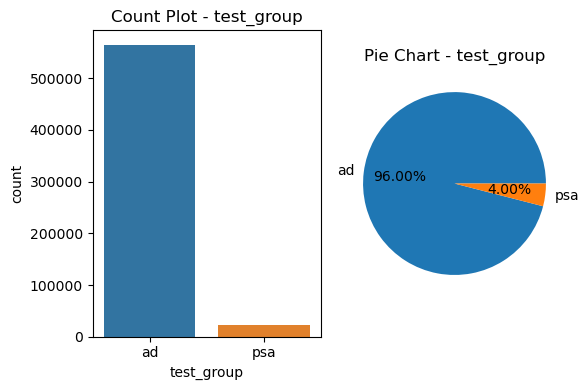

In [21]:
variable = 'test_group'

plt.figure(figsize = (6, 4))
# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x = variable, data = df_categorical)
plt.title(f"Count Plot - {variable}")

# Pie chart
plt.subplot(1, 2, 2)
counts = df_categorical[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct = '%0.2f%%')
plt.title(f"Pie Chart - {variable}")

# Adjust the layout
plt.tight_layout()

# Show the plots
plt.show()

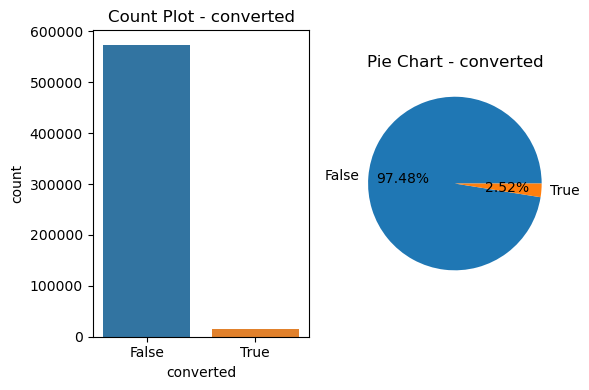

In [22]:
variable = 'converted'

plt.figure(figsize = (6, 4))
# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x = variable, data = df_categorical)
plt.title(f"Count Plot - {variable}")

# Pie chart
plt.subplot(1, 2, 2)
counts = df_categorical[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct = '%0.2f%%')
plt.title(f"Pie Chart - {variable}")

# Adjust the layout
plt.tight_layout()

# Show the plots
plt.show()

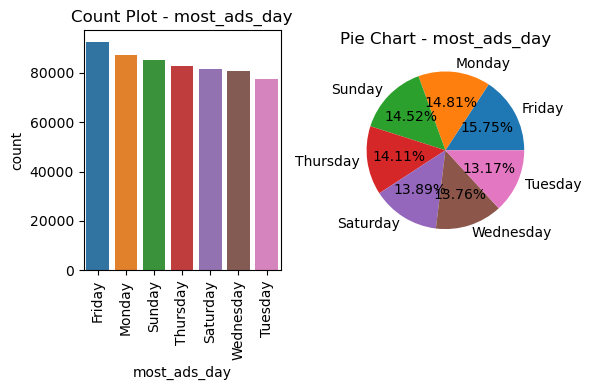

In [27]:
variable = 'most_ads_day'

plt.figure(figsize = (6, 4))
# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x = variable, data = df_categorical, order = df_categorical['most_ads_day'].value_counts().index)
plt.title(f"Count Plot - {variable}")
plt.xticks(rotation = 90)

# Pie chart
plt.subplot(1, 2, 2)
counts = df_categorical[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct = '%0.2f%%')
plt.title(f"Pie Chart - {variable}")

# Adjust the layout
plt.tight_layout()

# Show the plots
plt.show()

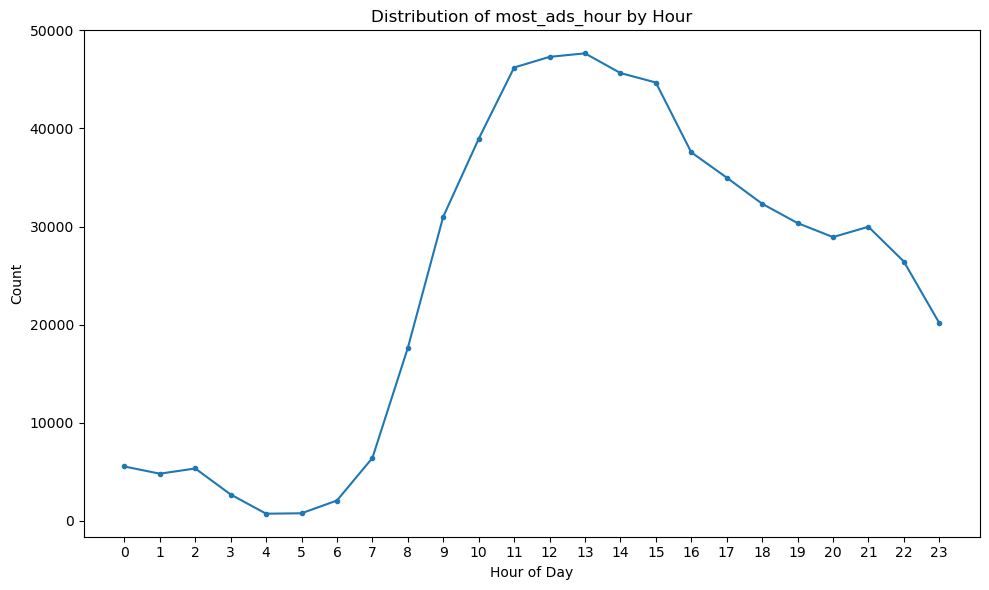

In [35]:
variable = 'most_ads_hour'

# Count the occurrences of each hour
hour_counts = df_categorical[variable].value_counts().sort_index()

# Create the line chart
plt.figure(figsize=(10, 6))
plt.plot(hour_counts.index, hour_counts.values, marker='.', linestyle='-', linewidth=1.5, markersize=6)

# Add labels and title
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.title(f'Distribution of {variable} by Hour')

# Customize x-axis ticks to show all hours
plt.xticks(range(24) if hour_counts.index.max() <= 23 else hour_counts.index)

plt.tight_layout()
plt.show()

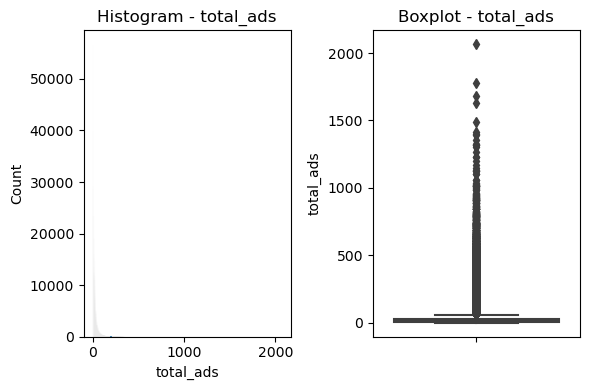

In [37]:
variable = 'total_ads'

plt.figure(figsize = (6, 4))
# Histogram
plt.subplot(1, 2, 1)
sns.histplot(x = variable, data = df)
plt.title(f'Histogram - {variable}')

# Pie chart
plt.subplot(1, 2, 2)
sns.boxplot(y = variable, data = df)
plt.title(f'Boxplot - {variable}')

# Adjust the layout
plt.tight_layout()

# Show the plots
plt.show()

In [38]:
# Let's check the descriptive stats of this feature

df['total_ads'].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total_ads, dtype: float64

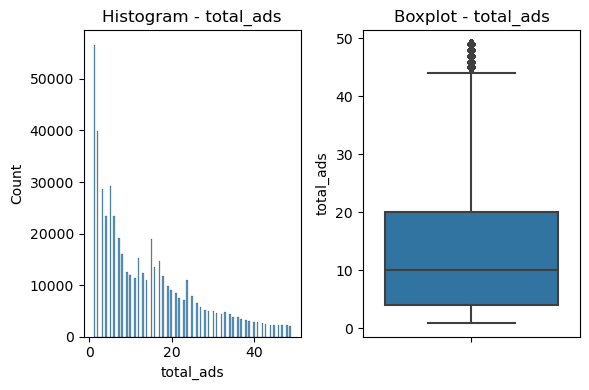

In [39]:
variable = 'total_ads'

plt.figure(figsize = (6, 4))
# Histogram
plt.subplot(1, 2, 1)

# Filter the data for a value close to only 75th percentile for better visualization 
sns.histplot(x = variable, data = df[df['total_ads'] < 50])
plt.title(f'Histogram - {variable}')

# Pie chart
plt.subplot(1, 2, 2)
sns.boxplot(y = variable, data = df[df['total_ads'] < 50])
plt.title(f'Boxplot - {variable}')

# Adjust the layout
plt.tight_layout()

# Show the plots
plt.show()

## Bivariate Analysis

In [40]:
df.columns

Index(['test_group', 'converted', 'total_ads', 'most_ads_day',
       'most_ads_hour'],
      dtype='object')

In [48]:
ct_conversion_test_group = pd.crosstab(df['test_group'], df['converted'], normalize = 'index')
ct_conversion_test_group

converted,False,True
test_group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


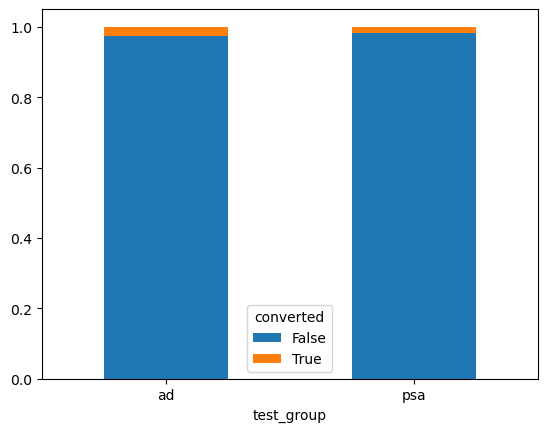

In [49]:
ct_conversion_test_group.plot.bar(stacked = True)
plt.xticks(rotation = 0);

converted        False     True 
most_ads_day                    
Monday        0.967188  0.032812
Tuesday       0.970160  0.029840
Wednesday     0.975058  0.024942
Sunday        0.975524  0.024476
Friday        0.977788  0.022212
Thursday      0.978429  0.021571
Saturday      0.978949  0.021051


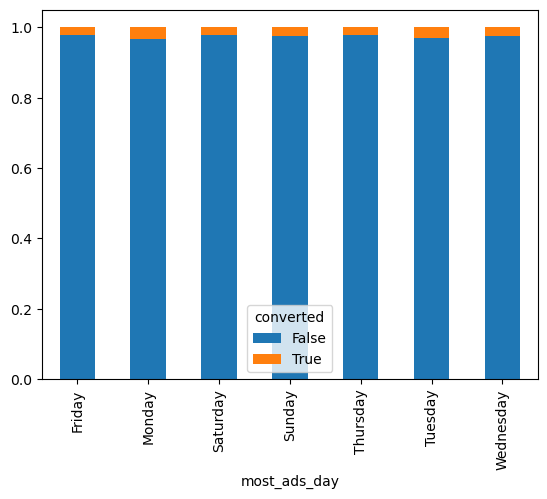

In [52]:
ct_conversion_day = pd.crosstab(df['most_ads_day'], df['converted'], normalize = 'index')
print(ct_conversion_day.sort_values(by = True, ascending = False))
ct_conversion_day.plot.bar(stacked = True);

converted         False     True 
most_ads_hour                    
16             0.969228  0.030772
20             0.970197  0.029803
15             0.970347  0.029653
21             0.971077  0.028923
17             0.971790  0.028210
14             0.971937  0.028063
18             0.972620  0.027380
19             0.973280  0.026720
22             0.973895  0.026105
13             0.975323  0.024677
12             0.976172  0.023828
23             0.977338  0.022662
6              0.977756  0.022244
11             0.977884  0.022116
10             0.978479  0.021521
5              0.979085  0.020915
8              0.980484  0.019516
9              0.980809  0.019191
0              0.981575  0.018425
7              0.981889  0.018111
4              0.984765  0.015235
1              0.987089  0.012911
3              0.989548  0.010452
2              0.992687  0.007313


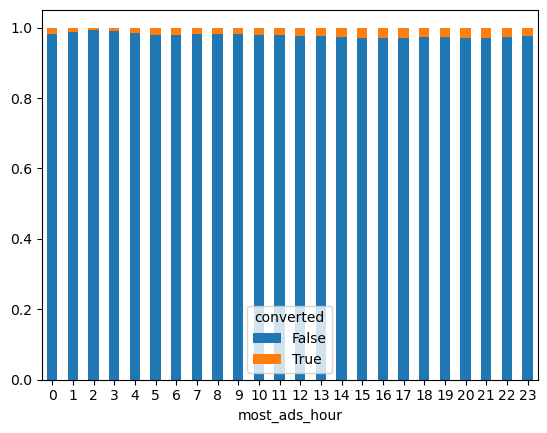

In [54]:
ct_conversion_hour = pd.crosstab(df['most_ads_hour'], df['converted'], normalize = 'index')
print(ct_conversion_hour.sort_values(by = True, ascending = False))
ct_conversion_hour.plot.bar(stacked = True)
plt.xticks(rotation = 0);

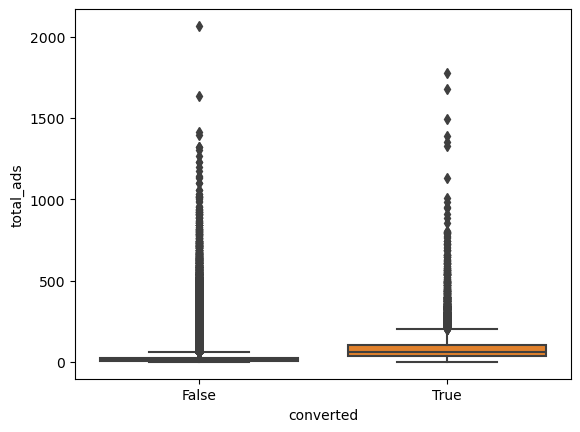

In [55]:
sns.boxplot(x = 'converted', y = 'total_ads', data = df); # skewed

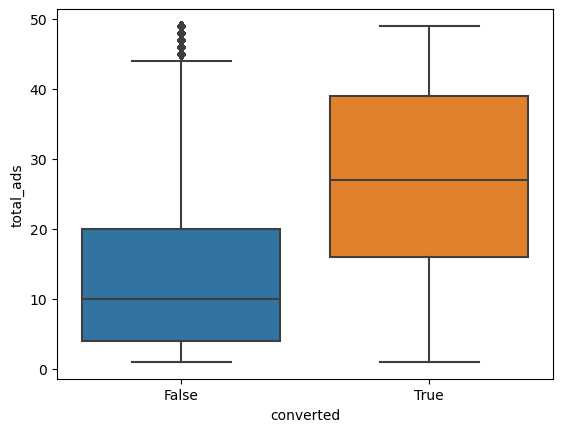

In [56]:
# Without outliers - more useful

# Repeated targeting seems to be helpful for conversion
sns.boxplot(x = 'converted', y = 'total_ads', data = df[df['total_ads'] < 50]);

### Null Hypothesis:

### There is no difference in conversion rates with respect to
### a categorical variable with multiple values

## Statistical Tests

In [57]:
# Chi-Square Test

# RESULTS:

# Showing the ads makes a difference!
# Which days and hours to show the ads also make a difference!

from scipy.stats import chi2_contingency

alpha = 0.05
for variable in df_categorical.columns:
    if variable != 'converted':
        # Generate a contingency table (cross-tabulation)
        contingency_table = pd.crosstab(df_categorical[variable], df_categorical['converted'])
        
        # Perform Chi-Square test
        chi2, p, _, _ = chi2_contingency(contingency_table)
        
        # Display the results
        print(f"\nChi-square test for {variable} vs. converted:")
        print(f"Chi-square value: {chi2}")
        print(f"p-value: {p}")
        
        # Check for significance
        if p < alpha:
            print(f"The difference in conversion rates across {variable} is statistically significant.")
        else:
            print(f"There is no significant difference in conversion rates across {variable}.")


Chi-square test for test_group vs. converted:
Chi-square value: 54.005823883685245
p-value: 1.9989623063390075e-13
The difference in conversion rates across test_group is statistically significant.

Chi-square test for most_ads_day vs. converted:
Chi-square value: 410.0478857936585
p-value: 1.932184379244731e-85
The difference in conversion rates across most_ads_day is statistically significant.

Chi-square test for most_ads_hour vs. converted:
Chi-square value: 430.76869230822086
p-value: 8.027629823696771e-77
The difference in conversion rates across most_ads_hour is statistically significant.


In [58]:
df_categorical.columns

Index(['test_group', 'converted', 'most_ads_day', 'most_ads_hour'], dtype='object')

In [64]:
# RESULT: Assumptions are not satisfied

from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

# Step 1: Check Assumptions
# Normality Assumption

shapiro_stat_true, shapiro_p_value_true = shapiro(df[df['converted'] == True]['total_ads'])
shapiro_stat_false, shapiro_p_value_false = shapiro(df[df['converted'] == False]['total_ads'])

print(f"Shapiro-Wilk test for normality (True group): p-value = {shapiro_p_value_true}")
print(f"Shapiro-Wilk test for normality (False group): p-value = {shapiro_p_value_false}")

# Equality of variances assumption

levene_stat, levene_p_value = levene(df[df['converted']]['total_ads'], df[~df['converted']]['total_ads'])
print(f"Levene's test for equality of variances: p-value = {levene_p_value}")

Shapiro-Wilk test for normality (True group): p-value = 0.0
Shapiro-Wilk test for normality (False group): p-value = 0.0
Levene's test for equality of variances: p-value = 0.0


In [63]:
''' RESULT: The median amount of total ads people see 
            make a difference for conversion '''

# Step 2: Perform a Suitable Test

alpha = 0.05

if shapiro_p_value_true > alpha and shapiro_p_value_false > alpha and levene_p_value > alpha:
    # Assumptions met - use t-test for means
    t_stat, t_p_value = ttest_ind(df[df['converted']]['total_ads'], df[~df['converted']]['total_ads'])
    print(f"Independent two-sample t-test: p-value = {t_p_value}")

else:
    # Assumptions not met - use Mann-Whitney U test for medians
    u_stat, u_p_value = mannwhitneyu(df[df['converted']]['total_ads'], df[~df['converted']]['total_ads'])
    print(f"Mann-Whitney U test: p-value = {u_p_value}")

Mann-Whitney U test: p-value = 0.0
